In [1]:
# For handling the timeseries
import pandas as pd, os, datetime
import numpy as np

# Statistical analysis
from scipy import stats
from scipy.stats import mannwhitneyu
import math

# For plotting
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import matplotlib.lines as mlines
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
pio.renderers.default = 'notebook'

# Import the loader function
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')
from process_code import load_generation_data

Dask dashboard: /proxy/8787/status


2025-12-08 09:58:13,954 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle cee544f46277e03a913ec0f30b38a86e initialized by task ('shuffle-transfer-cee544f46277e03a913ec0f30b38a86e', 0) executed on worker tcp://127.0.0.1:42147
2025-12-08 09:58:20,988 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle cee544f46277e03a913ec0f30b38a86e deactivated due to stimulus 'task-finished-1765148300.9230666'
2025-12-08 09:58:22,479 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle d2bf34415c6f40f73dd94d7619c24bee initialized by task ('shuffle-transfer-d2bf34415c6f40f73dd94d7619c24bee', 1) executed on worker tcp://127.0.0.1:41871
2025-12-08 09:58:27,454 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle d2bf34415c6f40f73dd94d7619c24bee deactivated due to stimulus 'task-finished-1765148307.1330469'


In [2]:
df, info = load_generation_data(
    sdate="2009-07-01",
    edate="2024-06-30",
    mode="hourly",
    ftype=["Wind"],
    apply_remove_negatives=True,
    apply_remove_wind_zeros=True,
    apply_min_heatwave_days=True,
    min_heatwave_days_threshold=20,
    apply_clear_agc=False
)

Read gen_details & hw_tseries with Dask: 0.11 sec
Select group: 0.00 sec
--- Starting Dask-Native Process ---


/g/data/ng72/ms5578/ID_HW_BARRA/process_code.py:168: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Starting final Dask compute...
Dask compute finished.

--- DASK TIMING REPORT ---
duid_setup: 0.00 seconds
csv_bulk_read: 5.29 seconds
filter_and_clean: 0.01 seconds
type_conversion_and_dropna: 0.03 seconds
date_filter: 0.01 seconds
hw_tseries_filter: 9.24 seconds
aggregate_hourly: 0.02 seconds
jitter: 0.19 seconds
final_merge: 0.02 seconds
compute: 72.14 seconds
--- END REPORT ---

Process group: 91.07 sec

--- DEBUG: Calculated Heatwave Days per Generator ---
DUID
MUSSELR1    334
SAPHWF1     206
WRWF1       201
HALLWF2     187
HALLWF1     187
GUNNING1    178
WOODLWN1    171
LKBONNY2    168
GULLRWF1    164
NBHWF1      162
WATERLWF    161
CLEMGPWF    158
SNOWTWN1    157
LKBONNY3    157
BLUFF1      151
TARALGA1    150
MEWF1       143
BOCORWF1    126
BODWF1      122
STWF1       115
SNOWNTH1    109
OAKLAND1    108
COOPGWF1    103
BALDHWF1    101
MACARTH1     98
HDWF1        98
HDWF2        92
HDWF3        92
SNOWSTH1     89
MERCER01     84
GRANWF1      84
CROOKWF2     76
ARWF1        72
K

In [16]:
df2 = df[df['EHF_flag']==0]
hour_df = df2[['DUID','time','TOTALMWh']].copy()
hour_df['hour'] = df['time'].dt.hour
hour_df['date'] = df['time'].dt.date
hour_df = pd.pivot_table(hour_df, index=df[['DUID','date']], columns='hour', values='TOTALMWh')
hour_df = hour_df.dropna()

In [17]:
hour_df

hour                        0           1           2           3   \
DUID    date                                                         
ARWF1   2016-06-23         0.0         0.0         0.0         0.0   
        2016-06-24         0.0         0.0         0.0         0.0   
        2016-06-25         0.0         0.0         0.0         0.0   
        2016-06-26         0.0         0.0         0.0         0.0   
        2016-06-27         0.0         0.0         0.0         0.0   
...                        ...         ...         ...         ...   
YENDWF1 2024-06-25  122.211671   118.39334  103.717504   78.134171   
        2024-06-26  125.109172  124.883341  123.470004  119.629171   
        2024-06-27   73.895837   65.179167   74.300837   50.668334   
        2024-06-28       64.75   64.656668   70.100834    98.88917   
        2024-06-29  124.927507  125.222509  125.021674  125.022505   

hour                        4           5           6           7   \
DUID    date                                                         
ARWF1   2016-06-23         0.0         0.0         0.0         0.0   
        2016-06-24         0.0         0.0         0.0         0.0   
        2016-06-25         0.0         0.0         0.0         0.0   
        2016-06-26         0.0         0.0         0.0         0.0   
        2016-06-27         0.0         0.0         0.0         0.0   
...                        ...         ...         ...         ...   
YENDWF1 2024-06-25   70.337505   75.616669   70.884171   73.081666   
        2024-06-26  124.165006  121.515838  119.275007  124.982506   
        2024-06-27   44.748333     43.7375   36.995001   45.550834   
        2024-06-28  104.750835  102.007503  122.236674  123.062504   
        2024-06-29  125.117506   124.90834  124.989172  124.992505   

hour                        8           9   ...          14          15  \
DUID    date                                ...                           
ARWF1   2016-06-23         0.0         0.0  ...         0.0         0.0   
        2016-06-24         0.0         0.0  ...         0.0         0.0   
        2016-06-25         0.0         0.0  ...         0.0         0.0   
        2016-06-26         0.0         0.0  ...         0.0         0.0   
        2016-06-27         0.0         0.0  ...         0.0         0.0   
...                        ...         ...  ...         ...         ...   
YENDWF1 2024-06-25   81.862504   95.570004  ...  124.913341   125.01167   
        2024-06-26  121.558338  105.423337  ...    80.18917   81.814172   
        2024-06-27   57.049167   57.905834  ...     36.1475   28.335833   
        2024-06-28  123.079172  124.400008  ...     124.985  121.404173   
        2024-06-29   124.86334  100.322503  ...     12.3025     15.7025   

hour                        16          17          18          19  \
DUID    date                                                         
ARWF1   2016-06-23         0.0         0.0         0.0         0.0   
        2016-06-24         0.0         0.0         0.0         0.0   
        2016-06-25         0.0         0.0         0.0         0.0   
        2016-06-26         0.0         0.0         0.0         0.0   
        2016-06-27         0.0         0.0         0.0         0.0   
...                        ...         ...         ...         ...   
YENDWF1 2024-06-25  122.693335   95.442504   85.330003  111.570834   
        2024-06-26   70.785836   74.449168   79.620835   74.520835   
        2024-06-27   25.360833   13.089167   22.040833   17.543333   
        2024-06-28  123.248339  124.555006  124.875839  124.853337   
        2024-06-29   17.379167   19.531667      26.525     24.0925   

hour                        20          21          22          23  
DUID    date                                                        
ARWF1   2016-06-23         0.0         0.0         0.0         0.0  
        2016-06-24         0.0         0.0         0.0         0.0  
        2016-06

In [18]:

# requires scipy for spearman p-values
try:
    from scipy.stats import spearmanr
except Exception as e:
    raise ImportError("scipy is required. Install with `pip install scipy`.") from e

def _ensure_lags(lags):
    if isinstance(lags, int):
        if lags < 1:
            raise ValueError("lags must be >= 1")
        return list(range(1, lags + 1))
    return sorted({int(x) for x in lags if int(x) >= 1})

def spearman_autocorr_from_pivot(hour_df, lags=1, min_pairs=3):
    """
    Compute Spearman autocorrelation across dates for each (DUID, hour) using your existing hour_df.

    hour_df: DataFrame with MultiIndex index (DUID, date) and columns = hours (e.g. 0..23)
             (This function DOES NOT re-create the pivot — it uses the DataFrame you already made.)
    lags: int (1..n) or iterable of lags
    min_pairs: minimum number of non-NaN paired observations required to compute the statistic

    Returns:
      DataFrame indexed by (DUID, hour) with columns spearman_stat_lag{L} and spearman_p_lag{L}.
    """
    if not isinstance(hour_df.index, pd.MultiIndex) or hour_df.index.nlevels < 2:
        raise ValueError("hour_df must have a MultiIndex index (DUID, date).")

    lags_to_test = _ensure_lags(lags)

    results = {}
    # group by DUID (level 0). This preserves the original date ordering in the subframe index; we sort to be safe.
    for duid, sub in hour_df.groupby(level=0):
        # remove the DUID level so index is the date only, then sort by date
        sub_by_date = sub.reset_index(level=0, drop=True).sort_index()
        for col in sub_by_date.columns:
            s = sub_by_date[col].astype(float)  # series over dates for this DUID/hour
            for L in lags_to_test:
                if s.size <= L:
                    stat, p = np.nan, np.nan
                else:
                    x = s.iloc[:-L].values
                    y = s.iloc[L:].values
                    mask = (~pd.isna(x)) & (~pd.isna(y))
                    x2 = x[mask]
                    y2 = y[mask]
                    if x2.size < min_pairs:
                        stat, p = np.nan, np.nan
                    else:
                        try:
                            stat, p = spearmanr(x2, y2)
                            stat = float(stat) if stat is not None else np.nan
                            p = float(p) if p is not None else np.nan
                        except Exception:
                            stat, p = np.nan, np.nan

                results.setdefault((duid, col), {})[f"spearman_stat_lag{L}"] = stat
                results[(duid, col)][f"spearman_p_lag{L}"] = p

    res_df = pd.DataFrame.from_dict(results, orient="index")
    if not res_df.empty:
        res_df.index = pd.MultiIndex.from_tuples(res_df.index, names=["DUID", "hour"])
        # sort columns by lag, stat before p
        def _col_key(c):
            import re
            m = re.search(r"lag(\d+)", c)
            if m:
                lag = int(m.group(1))
                typ = 0 if c.endswith(f"stat_lag{lag}") or "_stat_lag" in c else 1
                return (lag, typ, c)
            return (9999, c)
        res_df = res_df.reindex(columns=sorted(res_df.columns, key=_col_key))
    return res_df

# -------------------------
# Usage: run this cell below
# -------------------------
# Assumes `hour_df` is already in your notebook, with index (DUID, date) and columns = hours.
# Example: test lags 1..3 and show a preview
res = spearman_autocorr_from_pivot(hour_df, lags=3, min_pairs=3)
print("Spearman autocorrelation results (index = DUID, hour):")
display(res.head(50))

Spearman autocorrelation results (index = DUID, hour):


spearman_stat_lag1  spearman_p_lag1  spearman_stat_lag2  \
DUID     hour                                                            
ARWF1    0               0.286280     4.378284e-43            0.155581   
         1               0.300297     1.966847e-47            0.186682   
         2               0.302633     3.510493e-48            0.191517   
         3               0.316231     1.121584e-52            0.204935   
         4               0.316153     1.192681e-52            0.214699   
         5               0.313623     8.524377e-52            0.214680   
         6               0.314078     5.991633e-52            0.217833   
         7               0.325623     6.381163e-56            0.223612   
         8               0.339786     4.885560e-61            0.249480   
         9               0.346273     1.798879e-63            0.268617   
         10              0.356208     2.589654e-67            0.273332   
         11              0.368877     2.046682e-72            0.268924   
         12              0.380696     2.185056e-77            0.276678   
         13              0.383874     9.273397e-79            0.275424   
         14              0.373768     1.899929e-74            0.273785   
         15              0.363939     2.123363e-70            0.264391   
         16              0.351220     2.288076e-65            0.243681   
         17              0.352114     1.030807e-65            0.225652   
         18              0.322997     5.295475e-55            0.186103   
         19              0.326114     4.284223e-56            0.192004   
         20              0.313686     8.120119e-52            0.186637   
         21              0.308325     4.926382e-50            0.162239   
         22              0.276110     4.407451e-40            0.138819   
         23              0.257961     4.942242e-35            0.109436   
BALDHWF1 0               0.314216     2.181073e-77            0.120621   
         1               0.320736     9.876298e-81            0.121601   
         2               0.333069     2.739247e-87            0.132600   
         3               0.339342     9.651297e-91            0.136095   
         4               0.337834     6.643005e-90            0.141428   
         5               0.336208     5.245930e-89            0.149371   
         6               0.335432     1.401934e-88            0.149622   
         7               0.329859     1.491500e-85            0.138342   
         8               0.334188     6.729571e-88            0.132299   
         9               0.328648     6.661780e-85            0.125668   
         10              0.342908     9.681004e-93            0.136091   
         11              0.363663    6.616271e-105            0.150066   
         12              0.359659    1.733407e-102            0.159317   
         13              0.361978    6.953535e-104            0.155443   
         14              0.357325    4.294888e-101            0.144689   
         15              0.349943     9.209291e-97            0.129224   
         16              0.336724     2.727065e-89            0.126676   
         17              0.302810     9.754399e-72            0.100327   
         18              0.272663     5.497074e-58            0.077956   
         19              0.264248     1.908389e-54            0.066052   
         20              0.262439     1.060030e-53            0.075587   
         21              0.274221     1.176831e-58            0.082545   
         22              0.297176     4.878897e-69            0.098316   
         23              0.301942     2.564998e-71            0.105052   
BLUFF1   0               0.271452     7.022437e-75            0.081957   
         1               0.282912     1.920049e-81            0.084518   

               spearman_p_lag2  spearman_stat_lag3  spearman_p_lag3  
DUID     hour                                                        
ARWF1    0        1.776334

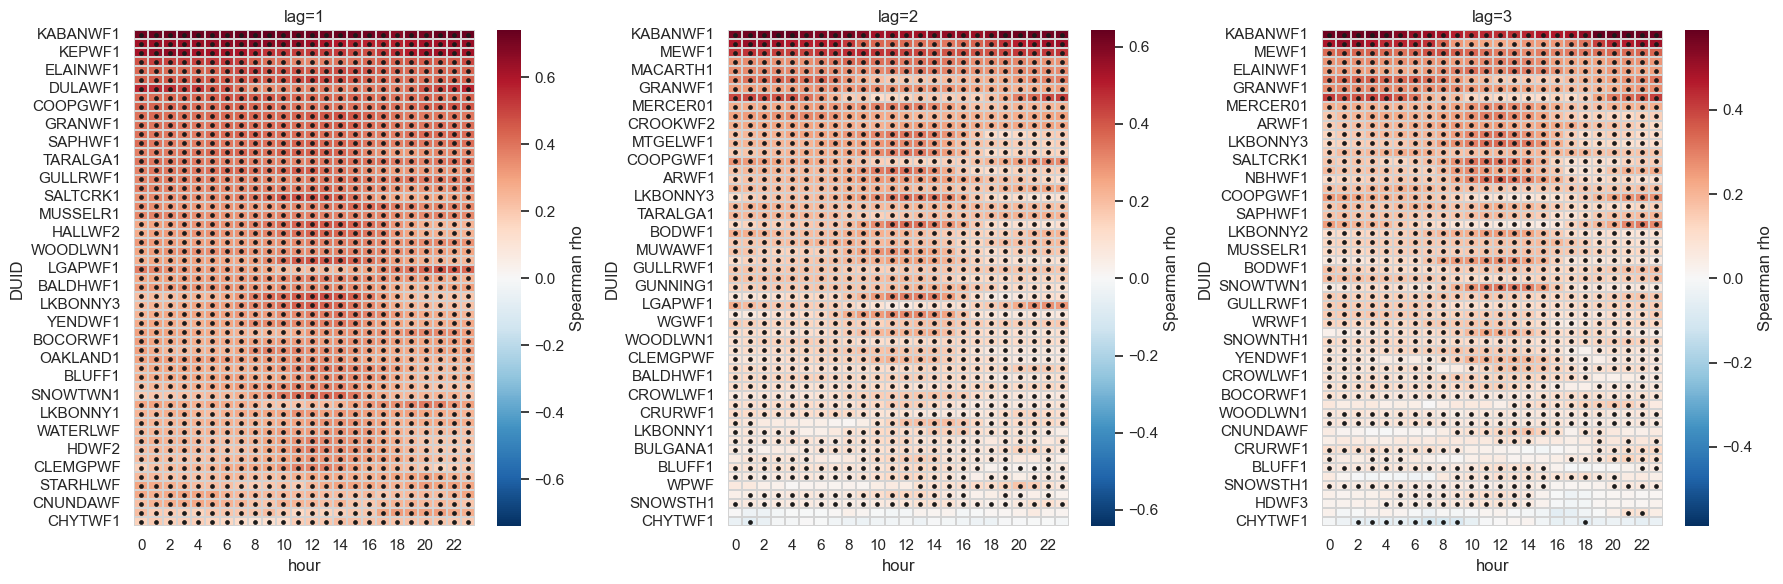

In [22]:
# seaborn is optional but gives nicer default styling
try:
    import seaborn as sns
    sns.set(style="white")
except Exception:
    sns = None

def plot_spearman_heatmap(
    res,
    lag=1,
    alpha=0.05,
    sort_by="mean",
    cmap="RdBu_r",
    figsize=(10, 8),
    show_sig=True,
    vmax_override=None,
):
    """
    Plot a heatmap of spearman_stat_lag{lag} with DUID rows and hour columns.

    Parameters
    ----------
    res : DataFrame
        Output from spearman_autocorr_from_pivot. Index must be MultiIndex (DUID, hour).
    lag : int
        Lag to visualize (uses column 'spearman_stat_lag{lag}' and optionally 'spearman_p_lag{lag}').
    alpha : float
        p-value threshold to mark significance if p-column exists (unadjusted).
    sort_by : {"mean", "none"} or list-like
        If "mean", sort DUIDs by the mean rho across hours (descending).
        If "none", preserve current order in res.unstack.
        Or pass a list of DUID order.
    cmap : str
        matplotlib / seaborn colormap.
    figsize : tuple
        figure size.
    show_sig : bool
        if True and p-column exists, overlay markers where p < alpha.
    vmax_override : float or None
        if provided, use this as the absolute vmin/vmax for color scale (symmetric around 0).
    """
    stat_col = f"spearman_stat_lag{lag}"
    p_col = f"spearman_p_lag{lag}"

    if stat_col not in res.columns:
        raise KeyError(f"{stat_col} not found in res.columns. Available cols: {list(res.columns)}")

    # build heat matrix: rows = DUID, cols = hour
    heat = res[stat_col].unstack(level="hour")
    # ensure hour columns are sorted numerically if possible
    try:
        heat = heat.reindex(sorted(heat.columns, key=lambda x: int(x)), axis=1)
    except Exception:
        pass

    # optional sorting of DUID rows
    if sort_by == "mean":
        order = heat.mean(axis=1).sort_values(ascending=False).index
        heat = heat.reindex(order)
    elif sort_by == "none":
        pass
    else:
        # allow user-provided order
        heat = heat.reindex(sort_by)

    # compute color scale symmetric around zero
    if vmax_override is not None:
        vmax = float(vmax_override)
    else:
        vmax = np.nanmax(np.abs(heat.values))
        if np.isnan(vmax) or vmax == 0:
            vmax = 0.5  # fallback
    vmin, vmax = -vmax, vmax

    fig, ax = plt.subplots(figsize=figsize)
    if sns is not None:
        sns.heatmap(
            heat,
            ax=ax,
            cmap=cmap,
            center=0,
            vmin=vmin,
            vmax=vmax,
            mask=heat.isna(),
            cbar_kws={"label": "Spearman rho"},
            linewidths=0.25,
            linecolor="lightgray",
        )
    else:
        # fallback using pcolormesh
        im = ax.pcolormesh(
            heat.columns.astype(str),
            np.arange(len(heat.index) + 1),
            np.nan_to_num(heat.values, nan=0.0),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
        plt.colorbar(im, ax=ax, label="Spearman rho")
        ax.set_xticks(np.arange(0.5, len(heat.columns) + 0.5))
        ax.set_xticklabels([str(c) for c in heat.columns], rotation=45)
        ax.set_yticks(np.arange(0.5, len(heat.index) + 0.5))
        ax.set_yticklabels(heat.index)

    ax.set_title(f"Spearman rho heatmap (lag={lag})")
    ax.set_xlabel("hour")
    ax.set_ylabel("DUID")

    # overlay significance markers if requested and p-column exists
    if show_sig and p_col in res.columns:
        pmat = res[p_col].unstack(level="hour")
        # align to heat ordering
        pmat = pmat.reindex(index=heat.index, columns=heat.columns)
        sig_mask = (pmat < alpha) & (~pmat.isna())
        # plot dots at centers of significant cells
        ys, xs = np.where(sig_mask.values)
        # mapping indices: heat rows 0..n-1 map to y positions in heatmap
        for (r, c) in zip(ys, xs):
            # scatter coordinates: x=col_index + 0.5, y=row_index + 0.5 for seaborn heatmap alignment
            ax.scatter(c + 0.5, r + 0.5, s=12, c="k", marker="o", linewidths=0.5)

    plt.tight_layout()
    return fig, ax

def plot_multiple_lags(res, lags=(1,2,3), alpha=0.05, figsize_per=(5,4), **kwargs):
    """Plot grid of heatmaps for multiple lags. Returns fig, axes list."""
    n = len(lags)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per[0], rows * figsize_per[1]))
    axes = np.array(axes).reshape(-1)
    for axi in axes[n:]:
        axi.axis("off")
    for i, lag in enumerate(lags):
        # temporarily set plt.current axes to reuse plot function (which creates its own fig)
        fig_i, ax_i = plot_spearman_heatmap(res, lag=lag, alpha=alpha, show_sig=kwargs.get("show_sig", True),
                                            cmap=kwargs.get("cmap", "RdBu_r"),
                                            figsize=figsize_per, sort_by=kwargs.get("sort_by", "mean"),
                                            vmax_override=kwargs.get("vmax_override", None))
        # copy contents of ax_i into the grid ax
        # simpler: draw into the grid by re-plotting using data
        plt.close(fig_i)  # close the small fig created by helper
        # draw directly with heat data to the grid axis
        stat_col = f"spearman_stat_lag{lag}"
        heat = res[stat_col].unstack(level="hour")
        try:
            heat = heat.reindex(sorted(heat.columns, key=lambda x: int(x)), axis=1)
        except Exception:
            pass
        if kwargs.get("sort_by", "mean") == "mean":
            heat = heat.reindex(heat.mean(axis=1).sort_values(ascending=False).index)
        ax = axes[i]
        if sns is not None:
            sns.heatmap(
                heat,
                ax=ax,
                cmap=kwargs.get("cmap", "RdBu_r"),
                center=0,
                vmin=-(np.nanmax(np.abs(heat.values)) if kwargs.get("vmax_override") is None else kwargs.get("vmax_override")),
                vmax=(np.nanmax(np.abs(heat.values)) if kwargs.get("vmax_override") is None else kwargs.get("vmax_override")),
                mask=heat.isna(),
                cbar_kws={"label": "Spearman rho"},
                linewidths=0.25,
                linecolor="lightgray",
            )
        else:
            im = ax.pcolormesh(
                heat.columns.astype(str),
                np.arange(len(heat.index) + 1),
                np.nan_to_num(heat.values, nan=0.0),
                cmap=kwargs.get("cmap", "RdBu_r"),
                shading="auto",
            )
            plt.colorbar(im, ax=ax, label="Spearman rho")
            ax.set_xticks(np.arange(0.5, len(heat.columns) + 0.5))
            ax.set_xticklabels([str(c) for c in heat.columns], rotation=45)
            ax.set_yticks(np.arange(0.5, len(heat.index) + 0.5))
            ax.set_yticklabels(heat.index)
            ax.tick_params(axis='y', labelsize=3)
        ax.set_title(f"lag={lag}")
        ax.set_xlabel("hour")
        ax.set_ylabel("DUID")
        # overlay significance for this lag if available
        p_col = f"spearman_p_lag{lag}"
        if kwargs.get("show_sig", True) and p_col in res.columns:
            pmat = res[p_col].unstack(level="hour")
            pmat = pmat.reindex(index=heat.index, columns=heat.columns)
            sig_mask = (pmat < alpha) & (~pmat.isna())
            ys, xs = np.where(sig_mask.values)
            for (r, c) in zip(ys, xs):
                ax.scatter(c + 0.5, r + 0.5, s=8, c="k", marker="o", linewidths=0.5)

    plt.tight_layout()
    return fig, axes

# -----------------------
# Example usage (run in notebook)
# -----------------------
# - requires `res` from spearman_autocorr_from_pivot to be in the notebook
# - pick a lag, e.g. lag = 1
# fig, ax = plot_spearman_heatmap(res, lag=1, alpha=0.05, sort_by="mean", figsize=(10, 8))
# plt.show()

# To plot multiple lags:
fig, axes = plot_multiple_lags(res, lags=(1,2,3), alpha=0.05, figsize_per=(6,6), show_sig=True)
plt.show()